# Data analysis on simulated data from fitted model

The pair statistics of [spatial_bmcd_data_analysis.ipynb](spatial_bmcd_data_analysis.ipynb) are read off the raw ECAD record. This notebook reads the same statistics, with the same code ([pair_statistics.py](pair_statistics.py), lifted from that notebook's cells), off **simulated data from fitted model** — the model fitted in [spatial_lin_mod_coregion_fit_spain_portugal.ipynb](spatial_lin_mod_coregion_fit_spain_portugal.ipynb), with $\widehat{\theta}_s$ per season from `experiment_outputs/theta_fit_spain_portugal_by_season_state_dep_lambda.csv` — and puts the two side by side:

1. the **occurrence raster**, observed data against simulated data from fitted model (cell 1.b of the fit notebook);
2. the **rain-state agreement** $\widehat{\pi}_{jj'}$ against distance, both on the same axes (black = observed data, blue = simulated data from fitted model);
3. the **co-persistence** $\widehat{p}^{\,\mathrm{stay}}_{jj'}(x,x')$ on the equal-duration cells $d = d' \le 20$: against distance on observed data, then on simulated data from fitted model; then the model value $p^{\,\mathrm{stay}}$ at $\widehat{\theta}$ against each of the two estimates.

Nothing is fitted here. The simulated data from fitted model are one trajectory on the observed calendar (1980–2020, 26 stations, seed `SEED`), blanked for every pair statistic where the observed data are missing, so the two sides are estimated on the same station-days. The same trajectory is used throughout: what the raster shows is what the statistics are read on.

**Reading.** The gap of a statistic between observed data and simulated data from fitted model is the sum of the model's departure and of the sampling noise of one 41-year draw. The last section's scatter of the model against simulated data from fitted model measures the second term alone: its spread is what the scatter of the model against observed data would show if the model were exactly right.

Figures are written to `figures/spatial/diag_fitted_model_*.pdf`, summary tables to `experiment_outputs/`. Neither the fit notebook's figures nor the article's are overwritten.

## Setup

Same cell as the fit notebook: single-site outputs of the data-preparation notebook, per-season PT/ES station subsets with their exit-probability closures $q^{(0)}, q^{(1)}$, raw daily rainfall, station set settled in two passes ([NOTES](NOTES_spatial_diagnostics.md) §1). Plus the constants of this notebook and the helpers it imports.

In [1]:
import sys, pathlib
_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd

from article_code.util_files import config
from spatial_bmcd.spatial_model import (
    prepare_station_fit_table,
    build_dict_model_params,
    load_all_station_rr,
    filter_stations_by_nan_fraction,
    build_joint_df_occurrence_from_raw_data,
    simulate_cholesky_seasonal,
)
from spatial_bmcd.spatial_diagnostics import (
    spatial_station_order,
    history_to_Rbin,
    plot_occurrence_raster_time_rows_pair,
)
from spatial_bmcd.spatial_plotting import SPATIAL_FIGURES_DIR
from spatial_bmcd.pair_statistics import (
    D_MAX,
    agreement_obs_vs_sim_summary,
    day_record_from_Rbin,
    equal_duration_metric_table,
    p00_cell_metrics,
    plot_agreement_obs_vs_sim,
    plot_equal_duration_metric_grid,
    season_frames,
    state_agreement_table,
)
from spatial_bmcd.switch_phi_duration_diagnostic import (
    p00_model_equal_duration,
    plot_psi_model_vs_obs_grid,
    psi_model_vs_obs_summary,
)

# Single-site outputs of the data-preparation notebook.
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)
stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

# Per-season PT/ES station subsets and exit-probability closures q0/q1.
COUNTRIES = ["PT", "ES"]
SEASONS = list(config.SEASONS)          # spring, summer, autumn, winter
YEAR_MIN, YEAR_MAX = 1980, 2020

# --- constants of this notebook ---------------------------------------------
SEED = 0                # simulated data from fitted model; seed 0 is the trajectory of cell 1.b of the fit notebook
N_BURN = 1000           # burn-in days prepended along the real season sequence
P00_MIN_N = 20          # admissibility rule of every p^stay figure (data-analysis notebook)
HEAVY_DRY_MIN_DAYS = 10 # raster: running dry age from which a day is drawn "heavy dry"

COLOR_OBS, COLOR_SIM = "black", "steelblue"
LABEL_OBS = "observed data"
LABEL_SIM = "simulated data from fitted model"

OUTPUT_DIR = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = SPATIAL_FIGURES_DIR           # ../figures/spatial
FIG_DIR.mkdir(parents=True, exist_ok=True)


def build_params_by_season(stations_used):
    """Per-season {city: model parameters} of the PT/ES subset of `stations_used`."""
    out = {}
    for season in SEASONS:
        df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
            df_fit_dry, df_fit_wet, stations_used, countries=COUNTRIES, season=season,
        )
        out[season] = build_dict_model_params(
            df_fit_dry_sub, df_fit_wet_sub, spells, season=season, show_progress=False,
        )
    return out

# Station set, settled in two passes (NOTES_spatial_diagnostics.md, section 1).
per_season_params = build_params_by_season(stations_used)
stations_union = sorted(set().union(*(p.keys() for p in per_season_params.values())))
# Raw daily RR, loaded once for the union of stations across seasons.
dfs_by_city = load_all_station_rr(config.ECAD_RAW_DIR, stations_to_get=stations_union, verbose=False)

stations_used = filter_stations_by_nan_fraction(stations_used, dfs_by_city)
per_season_params = build_params_by_season(stations_used)
stations_union = sorted(set().union(*(p.keys() for p in per_season_params.values())))
dfs_by_city = {c: df for c, df in dfs_by_city.items() if c in stations_union}

print(f"{len(spells)} stations in spells JSON; PT/ES stations per season: "
      + ", ".join(f"{s}={len(per_season_params[s])}" for s in SEASONS)
      + f"; raw RR loaded for {len(dfs_by_city)}/{len(stations_union)} stations")

NaN filter (1980-2020, max 50% missing): 26/35 assessed stations kept
  dropped: BEARIZ (52%), FISTERRA (53%), ALMEIDINHA (54%), CAMPI (59%), TAVIRA (63%), GUARDA (66%), ENCISO (81%), HUELVA (90%), LLEIDA-AJUNTAMENT (100%)


209 stations in spells JSON; PT/ES stations per season: spring=26, summer=26, autumn=26, winter=26; raw RR loaded for 26/26 stations


## $\widehat{\theta}_s$ and simulated data from fitted model

$\widehat{\theta}_s = (\hat\lambda^{(0)}, \hat\lambda^{(1)}, \hat\sigma_{w^c}, \hat\sigma_{w^{(0)}}, \hat\sigma_{w^{(1)}})$ per season is read from the CSV the fit notebook's Part 1 writes (last row of a season kept if it was appended twice — its own loader ends up with the same). No MLE is re-run.

The simulated data from fitted model are one continuous trajectory on the observed daily calendar (seed `SEED`), drawn by the seasonal Cholesky algorithm of `simulate_cholesky_seasonal` — latent fields switching to $\widehat{\theta}_{s(n)}$ on the first day of each season, exit probabilities keeping the season the spell started in, `N_BURN` days of burn-in discarded ([NOTES](NOTES_spatial_diagnostics.md) §2). It is kept twice:

- `Rbin_sim`, the full trajectory — what the raster of the next section draws, as in the fit notebook;
- `Rbin_sim_masked`, the same trajectory blanked wherever the observed data are missing — what every pair statistic reads, so that $N_{jj'}$ and the admissibility rules act on the same station-days on both sides.

In [2]:
THETA_KEYS = ["lam0", "lam1", "sigma_wc", "sigma_w0", "sigma_w1"]
theta_csv = OUTPUT_DIR / "theta_fit_spain_portugal_by_season_state_dep_lambda.csv"
if not theta_csv.exists():
    raise FileNotFoundError(
        f"{theta_csv} not found: run the model's fit section (Part 1) of the fit notebook once."
    )
df_theta = pd.read_csv(theta_csv, index_col="season")
# `fit_theta_by_season` appends a row per season, so a re-run can leave a season
# in the CSV twice; keep the last row of each, as the fit notebook's own
# `load_theta_by_season` ends up doing.
df_theta = df_theta[~df_theta.index.duplicated(keep="last")]
theta_by_season = {s: tuple(float(df_theta.loc[s, k]) for k in THETA_KEYS) for s in SEASONS}
print("model -- theta_hat per season:")
print(df_theta.loc[SEASONS, THETA_KEYS + ["ll"]].round(4).to_string())

# Common station set and observed full-calendar occurrence matrix (0/1/NaN, all seasons).
stations = sorted(
    set(dfs_by_city).intersection(*(set(p) for p in per_season_params.values()))
)
Rbin_obs = build_joint_df_occurrence_from_raw_data(
    dfs_by_city, season="all", station_names=stations,
    wet_day_threshold=float(config.WET_DAY_THRESHOLD),
)
Rbin_obs = Rbin_obs.loc[(Rbin_obs.index.year >= YEAR_MIN) & (Rbin_obs.index.year <= YEAR_MAX)]

# Simulated data from fitted model: one trajectory on the observed calendar.
Rbin_sim = history_to_Rbin(simulate_cholesky_seasonal(
    Rbin_obs.index, theta_by_season, per_season_params,
    station_names=stations, n_burn=N_BURN, seed=SEED,
))
# The same simulated data blanked where the observed data are missing: what
# the pair statistics below read, so both sides use the same station-days.
Rbin_sim_masked = Rbin_sim.where(Rbin_obs.notna())

_obs_days = Rbin_obs.notna()
print(f"\nobserved data {Rbin_obs.shape} (days x stations), "
      f"{100 * (1 - _obs_days.to_numpy().mean()):.1f}% station-days missing; "
      f"simulated data from fitted model {Rbin_sim.shape}, seed {SEED}")
print("wet-day fraction over the observed station-days: "
      f"observed data {Rbin_obs.stack().mean():.4f}, "
      f"simulated data from fitted model {Rbin_sim_masked.stack().mean():.4f}")

model -- theta_hat per season:
          lam0    lam1  sigma_wc  sigma_w0  sigma_w1           ll
season                                                           
spring  0.2935  0.7102  579.4817  470.4856    3.3952 -533054.6409
summer  0.8639  0.2946  337.2205  318.5314  287.3257 -298405.8477
autumn  0.3829  0.5691  689.0578  527.9703  122.1870 -513087.6563
winter  0.3499  0.6349  783.8115  530.0983   84.1087 -487591.7924



observed data (14976, 26) (days x stations), 15.0% station-days missing; simulated data from fitted model (14976, 26), seed 0
wet-day fraction over the observed station-days: observed data 0.2350, simulated data from fitted model 0.2194


## 1.b Observed vs simulated occurrence

The cell of the fit notebook, titles aside: occurrence raster, observed data against simulated data from fitted model, on the same calendar, station order (seriation of the distance matrix, [NOTES](NOTES_spatial_diagnostics.md) §2) and reading grid, over the first ten years. The panel of simulated data from fitted model is the unmasked trajectory, as there.

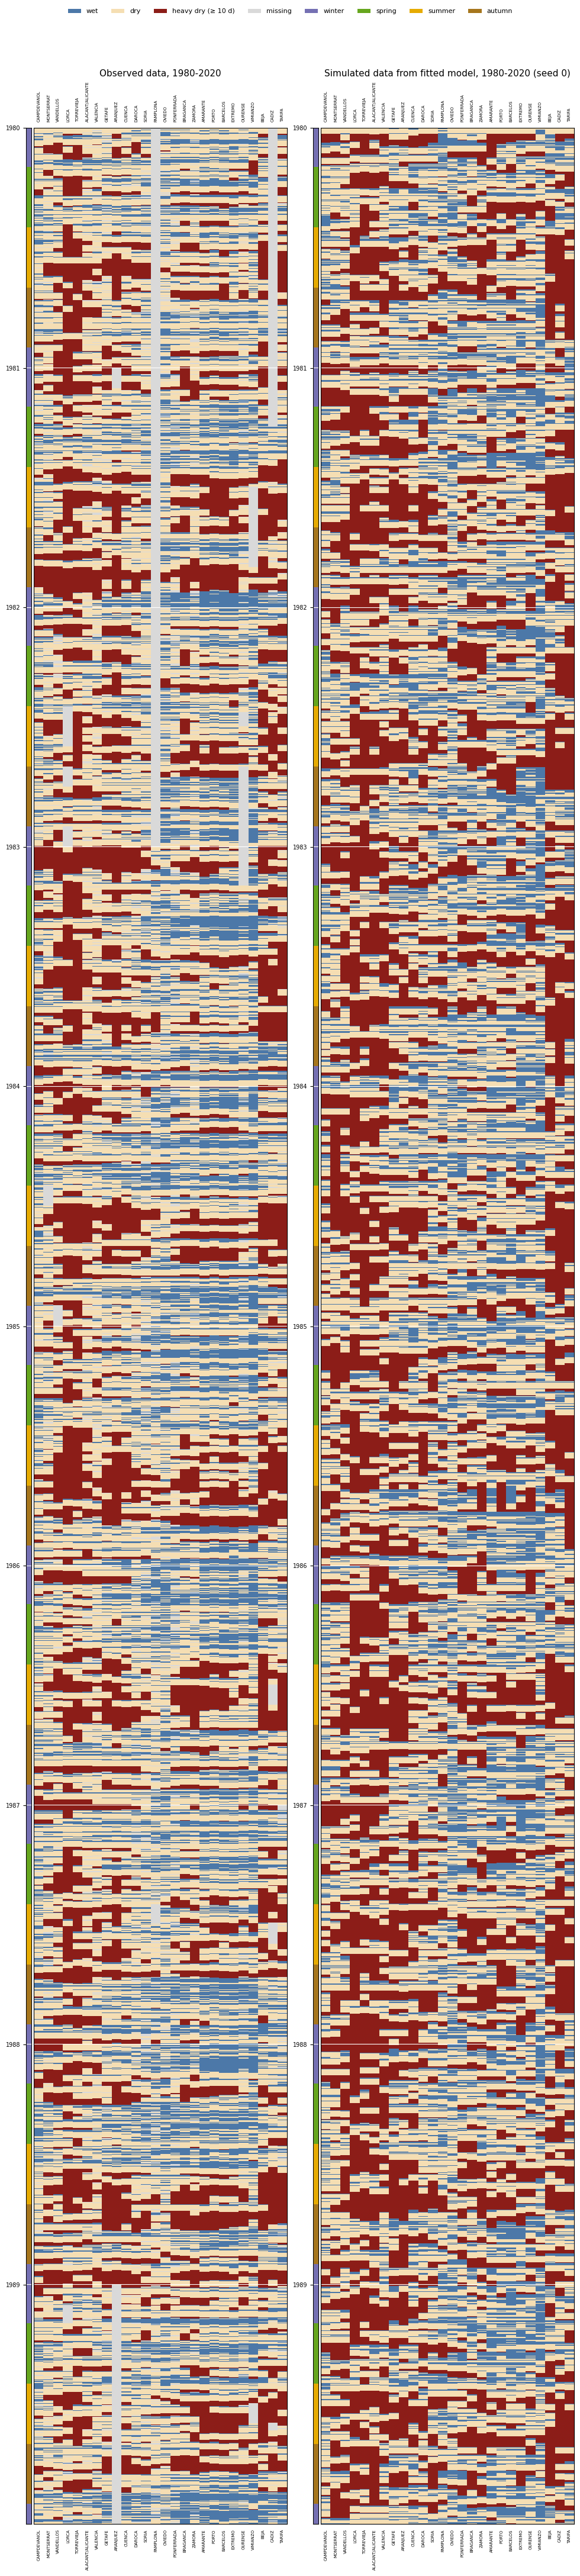

In [3]:
# Normalised coordinates are (near-)identical across seasons; use spring's.
params_xy = {c: per_season_params["spring"][c] for c in stations}
order = spatial_station_order(params_xy, stations)

_ = plot_occurrence_raster_time_rows_pair(
    Rbin_obs, Rbin_sim, params_xy, order=order,
    heavy_dry_min_days=HEAVY_DRY_MIN_DAYS,
    titles=("Observed data, 1980-2020",
            f"Simulated data from fitted model, 1980-2020 (seed {SEED})"),
    filename="diag_fitted_model_occurrence_obs_vs_sim.pdf",
    station_width=0.15,
    time_window=("1980", "1989"),
    figsize=(24, 44),
)

## Rain-state agreement between stations: $\widehat{\pi}_{jj'}$

For a station pair $(j,j')$ and the set $\mathcal{N}_{jj'}$ of the $N_{jj'}$ days of the season on which both stations are observed,

$$
\widehat{\pi}_{jj'} \;=\; \frac{1}{N_{jj'}}\sum_{n\in\mathcal{N}_{jj'}} \mathbf{1}\big(r_{n,j}=r_{n,j'}\big),
$$

the share of the common days on which the two stations are in the same rain state — the statistic of §2.1 of the article, `state_agreement_table` of the data-analysis notebook. Computed season by season, on observed data and on simulated data from fitted model: since the latter are blanked where the observed data are missing, $\mathcal{N}_{jj'}$ is the same set of days on both sides, and a pair sits on one vertical line in the two colours.

**Reading.** Black is observed data, the cloud of the article's Figure `fig:state_agreement_seasons` (same axes, $[0.35, 1]$). Blue, simulated data from fitted model, should reproduce its level *and* its decay with distance; `trend=True` adds the two binned medians, which make the comparison legible where the clouds overlap. Since $\widehat{\pi}_{jj'} = \widehat{\pi}^{\,\perp}_{jj'} + 2\,\widehat{\mathrm{Cov}}(r_{\cdot,j}, r_{\cdot,j'})$, a level offset at every distance points at the marginals (wet-day frequencies) and a different slope at the spatial dependence. The table gives the $N$-weighted bias and RMSE of the estimate on simulated data from fitted model against the one on observed data, pair by pair, and the Spearman correlation of each with distance.

pi_hat on simulated data from fitted model against pi_hat on observed data, pair by pair:
        n_pairs  obs median  sim median  bias (sim - obs, N-w.)  rmse (N-w.)  corr (pairs)  spearman(obs, h)  spearman(sim, h)
season                                                                                                                        
spring      325       0.722       0.673                  -0.040        0.061         0.837            -0.723            -0.643
summer      325       0.827       0.813                  -0.015        0.027         0.959            -0.394            -0.312
autumn      325       0.744       0.710                  -0.022        0.054         0.817            -0.697            -0.518
winter      325       0.728       0.664                  -0.043        0.070         0.835            -0.698            -0.597


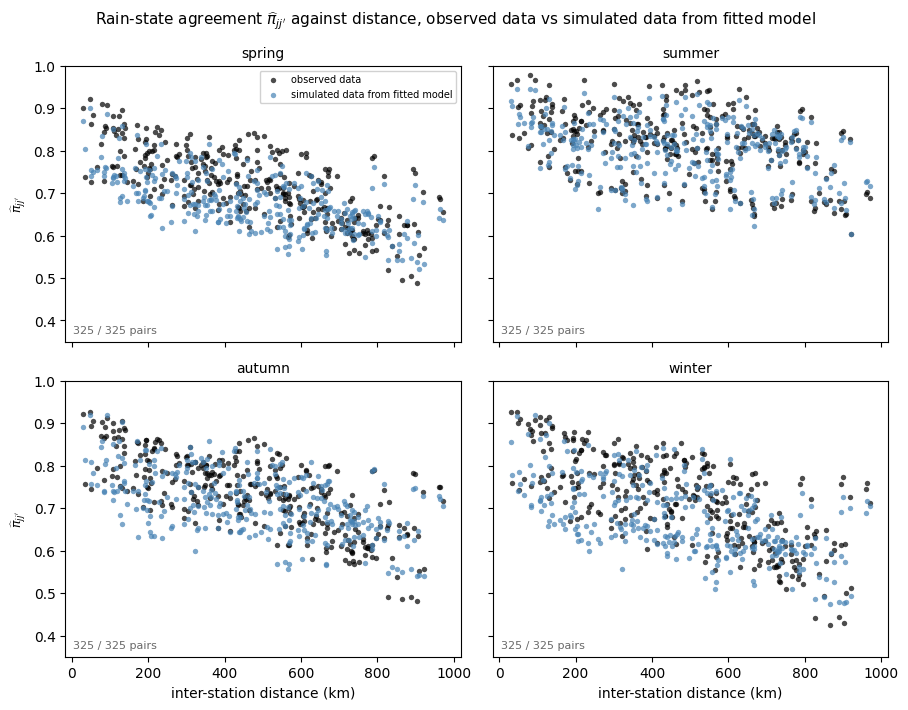

In [4]:
Rbin_obs_by_season = season_frames(Rbin_obs, SEASONS)
Rbin_sim_by_season = season_frames(Rbin_sim_masked, SEASONS)

agree_obs = {s: state_agreement_table(Rbin_obs_by_season[s], per_season_params[s])
             for s in SEASONS}
agree_sim = {s: state_agreement_table(Rbin_sim_by_season[s], per_season_params[s])
             for s in SEASONS}

fig_agree = plot_agreement_obs_vs_sim(
    agree_obs, agree_sim,
    labels=(LABEL_OBS, LABEL_SIM), colors=(COLOR_OBS, COLOR_SIM),
    ncols=2, trend=False,
    y_range=(0.35, 1.0),   # article Figure 1: a fixed axis, not the data span
    suptitle=r"Rain-state agreement $\widehat{\pi}_{jj'}$ against distance, "
             "observed data vs simulated data from fitted model",
    filenames=[FIG_DIR / "diag_fitted_model_state_agreement_obs_vs_sim.pdf"],
)

agree_summary = agreement_obs_vs_sim_summary(agree_obs, agree_sim)
agree_summary.to_csv(OUTPUT_DIR / "state_agreement_obs_vs_sim_summary.csv")
print("pi_hat on simulated data from fitted model against pi_hat on observed data, pair by pair:")
print(agree_summary.round(3).to_string())

## Co-persistence probability $\widehat{p}^{\,\mathrm{stay}}$ against distance — observed data, then simulated data from fitted model

For every station pair and common spell age $d = d' \le 20$, the probability that **neither** station leaves its spell,

$$p^{\,\mathrm{stay}}_{jj'}(x,x') = \mathbb{P}\big(B_{n,j} = B_{n,j'} = 0 \;\big|\; X_{n,j} = x,\; X_{n,j'} = x'\big),
\qquad
\widehat{p}^{\,\mathrm{stay}}_{jj'} = \frac{\#\{n \in \mathcal{N}_{jj'}(x,x') : b_{n,j} = b_{n,j'} = 0\}}{N_{jj'}(x,x')},$$

drawn at $N_{jj'}(x,x') \geq 20$ — the figure `diag_p00_equal_duration_seasons` of the data-analysis notebook. Observed data and simulated data from fitted model go through the same pipeline: per-season frame → day-level record $(R, D, B)$ with the ambiguous spells masked as in the likelihood (`day_record_from_Rbin`) → one row per (pair, $r$, $r'$, $d = d'$) (`equal_duration_metric_table`). The first figure is read on observed data, the second on simulated data from fitted model.

**Reading.** Same grid, same encoding (colour = $d$, dot area and opacity $\propto \sqrt{N}$ under one shared reference, crimson = $N$-weighted bin mean). The cells of simulated data from fitted model are redrawn by the simulation — each carries its own $N_{jj'}(x,x')$, close to but not equal to the observed one — so the dot counts differ: by little in the concordant classes, by far in the dry-wet class (counts printed below). What has to match is the level of the crimson curve per class and its slope with distance; the spread of the cloud around it is largely the noise of small cells and is expected on both sides.

[spring]  3731 days x 26 stations; cells with N >= 20: observed data  1921, simulated data from fitted model  1540
[summer]  3731 days x 26 stations; cells with N >= 20: observed data   848, simulated data from fitted model   712
[autumn]  3690 days x 26 stations; cells with N >= 20: observed data  1911, simulated data from fitted model  1339
[winter]  3660 days x 26 stations; cells with N >= 20: observed data  1785, simulated data from fitted model  1326


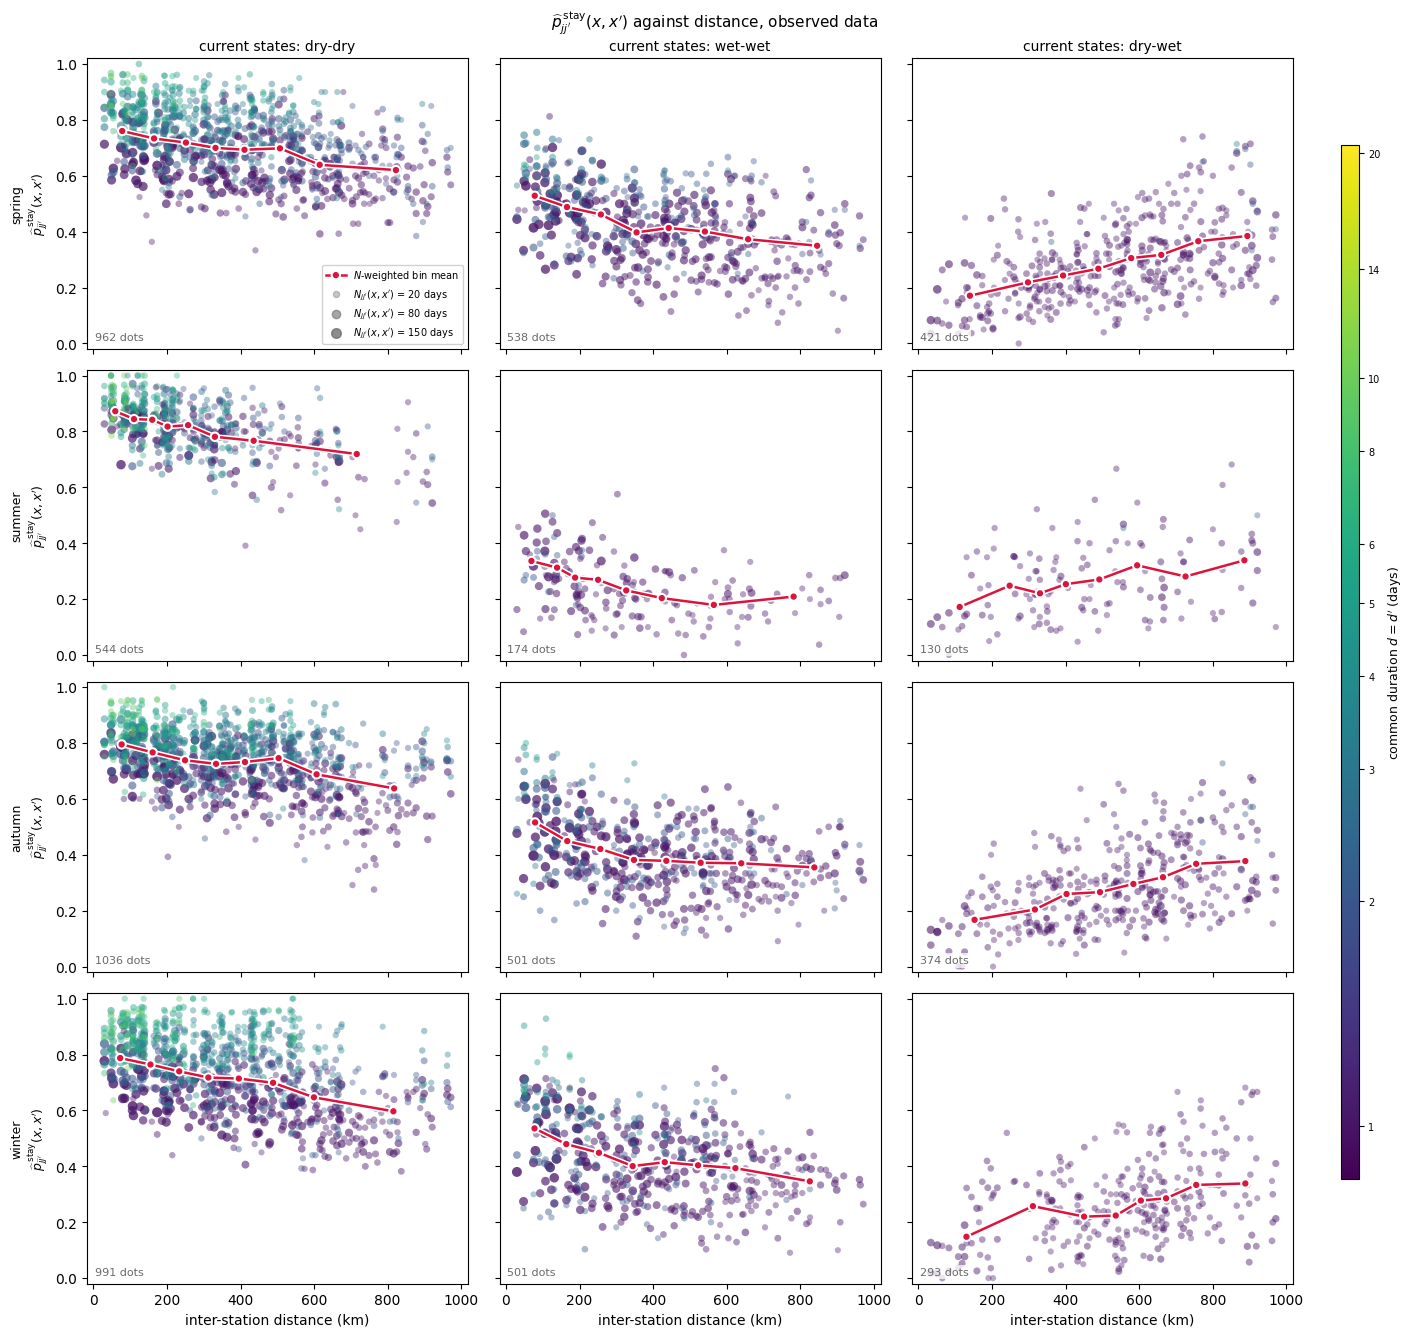

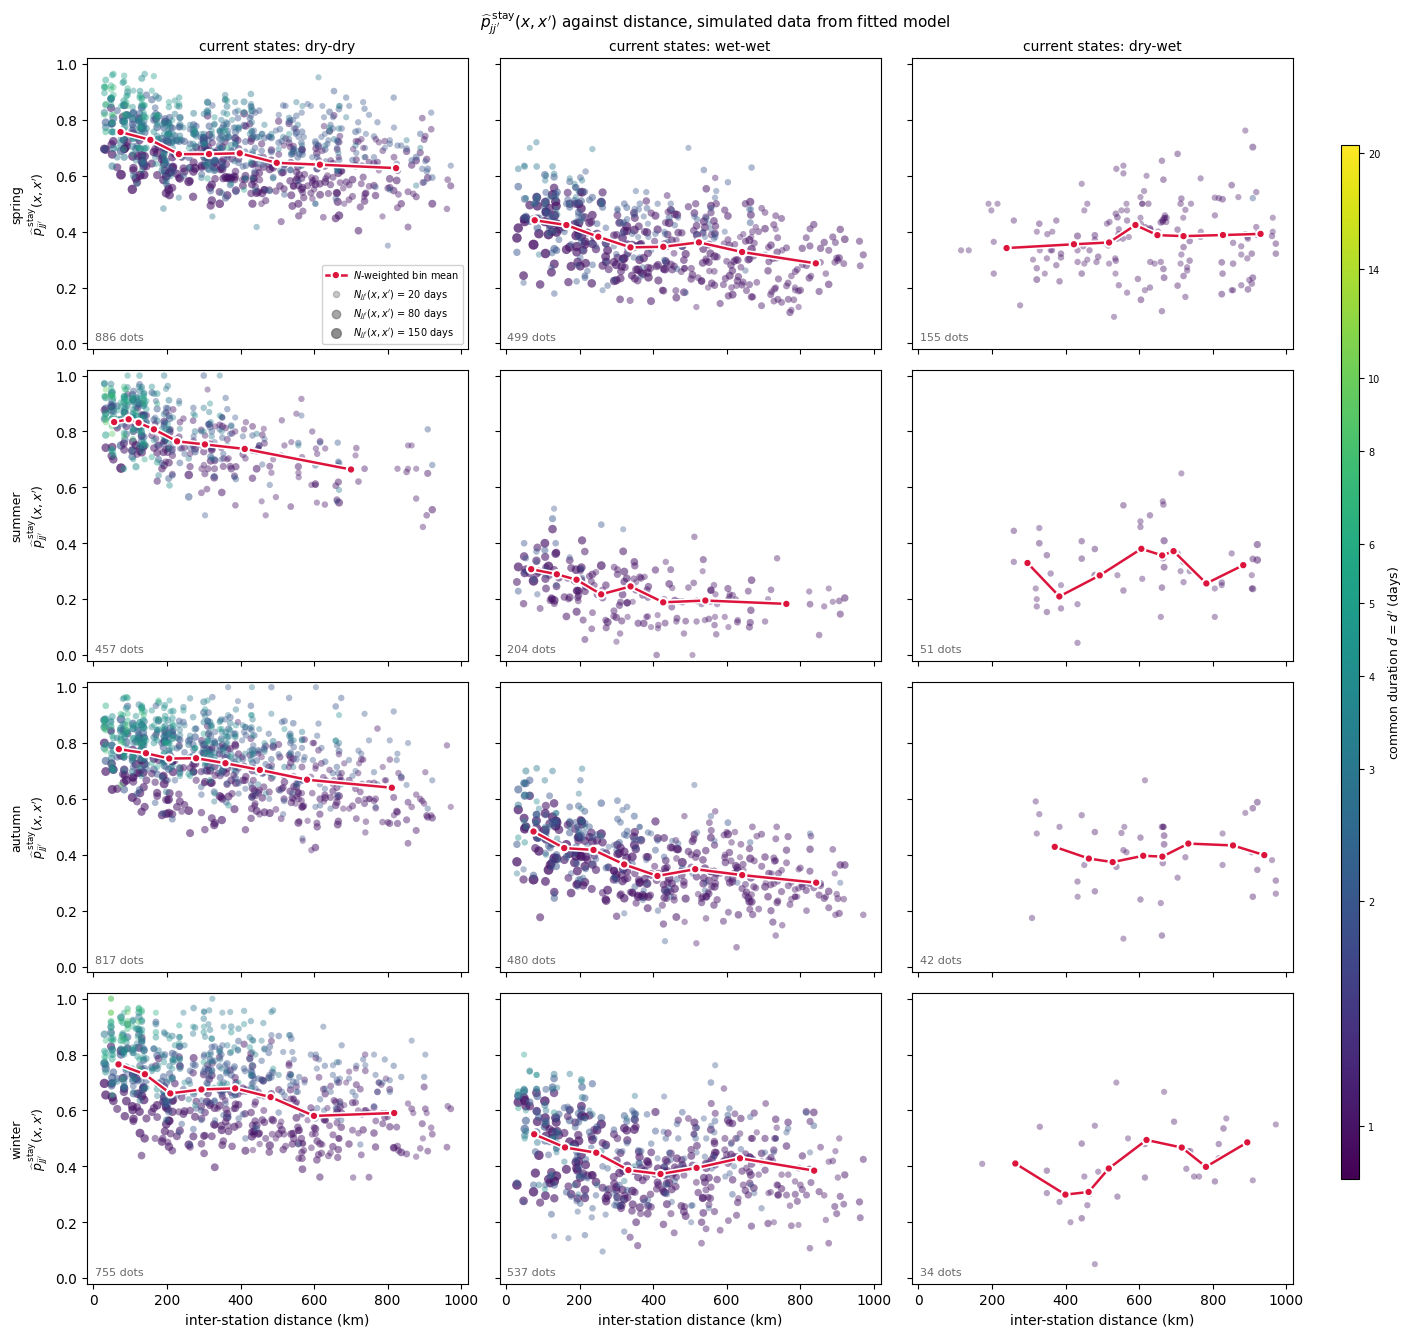

In [5]:
day_record_obs = {s: day_record_from_Rbin(Rbin_obs_by_season[s], per_season_params[s])
                  for s in SEASONS}
day_record_sim = {s: day_record_from_Rbin(Rbin_sim_by_season[s], per_season_params[s])
                  for s in SEASONS}

p00_obs = {s: equal_duration_metric_table(day_record_obs[s], p00_cell_metrics)
           for s in SEASONS}
p00_sim = {s: equal_duration_metric_table(day_record_sim[s], p00_cell_metrics)
           for s in SEASONS}

# One shared dot-size reference, so every p^stay figure of the notebook is comparable.
N_REF_P00 = float(max(t["n_days"].max() for t in (*p00_obs.values(), *p00_sim.values())))

for s in SEASONS:
    n_o = int((p00_obs[s]["n_days"] >= P00_MIN_N).sum())
    n_s = int((p00_sim[s]["n_days"] >= P00_MIN_N).sum())
    print(f"[{s:>6}] {day_record_obs[s]['B'].shape[0]:>5} days x "
          f"{day_record_obs[s]['B'].shape[1]} stations; cells with N >= {P00_MIN_N}: "
          f"observed data {n_o:>5}, simulated data from fitted model {n_s:>5}")

P00_LABEL = r"$\widehat{p}^{\,\mathrm{stay}}_{jj'}(x,x')$"
for tag, tables, label in (("obs", p00_obs, LABEL_OBS), ("sim", p00_sim, LABEL_SIM)):
    plot_equal_duration_metric_grid(
        tables, value_col="p00", value_label=P00_LABEL,
        y_range=(-0.02, 1.02),
        min_n=P00_MIN_N, n_ref=N_REF_P00, legend_ns=(20, 80, 150),
        suptitle=P00_LABEL + f" against distance, {label}",
        filenames=[FIG_DIR / f"diag_fitted_model_p00_equal_duration_{tag}.pdf"],
    )

## The same cells through the model — $p^{\,\mathrm{stay}}$ at $\widehat{\theta}$ against each estimate

The model gives a *value* for every cell above,

$$p^{\,\mathrm{stay}}_{jj'}(x,x') = 1 - q^{(r)}_{\mathbf{s}_j}(d) - q^{(r')}_{\mathbf{s}_{j'}}(d) + \Phi_2\big(z_{\mathbf{s}_j}(r,d),\, z_{\mathbf{s}_{j'}}(r',d);\, \rho^{(r,r')}_{jj'}\big),$$

verbatim the $(0,0)$ term of the pairwise composite likelihood (`p00_model_equal_duration`, with the single-site $q$'s of `per_season_params` and the LMC block at $\widehat{\theta}_s$). It goes on the $y$-axis against the estimate on the $x$-axis: first $\widehat{p}^{\,\mathrm{stay}}$ on observed data — the figure `diag_p00_model_vs_obs_equal_duration` of the data-analysis notebook — then $\widehat{p}^{\,\mathrm{stay}}$ on simulated data from fitted model. Same cells, same $N \ge 20$ rule, same encoding, same square window; grey dashed = identity.

**Reading.** On the second figure every departure from the identity line is estimation noise: the data *were* generated by the model at $\widehat{\theta}$. Its panel-by-panel bias, RMSE and correlation (right half of the table) are therefore the values the first figure would show if the model were exactly right, and whatever the first figure shows on top of them is what is left for a genuine model departure. Recall from the data-analysis notebook that $p^{\,\mathrm{stay}}$ is dominated by the margins, so both clouds hug the identity largely because the single-site $q$'s are right; the spatial statement is in the *difference* between the two halves of the table, class by class — in particular the dry-wet class, where the observed side sits systematically below the model.

p^stay at theta_hat against the estimate, N-weighted -- left: observed data, right: simulated data from fitted model (pure estimation noise)
               vs observed data                                       vs simulated data from fitted model                                      
                         n_dots bias (model - obs)   rmse corr (N-w.)                              n_dots bias (model - obs)   rmse corr (N-w.)
season class                                                                                                                                   
spring dry-dry              962              0.001  0.073       0.773                                 886              0.009  0.069       0.754
       wet-wet              538             -0.045  0.087       0.815                                 499              0.015  0.066       0.799
       dry-wet              421              0.106  0.155       0.594                                 155              0.034  0.098       0

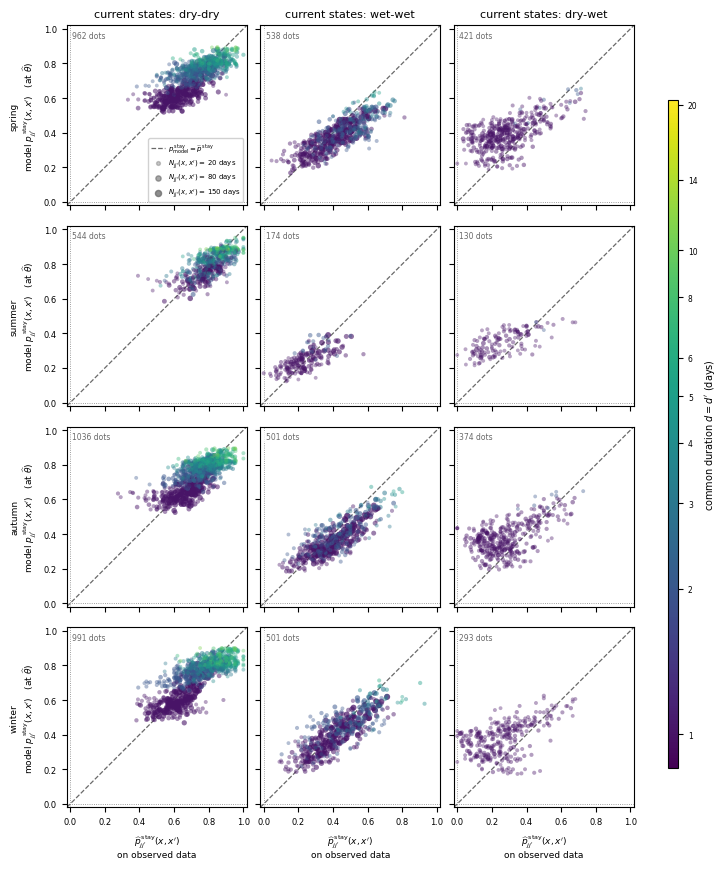

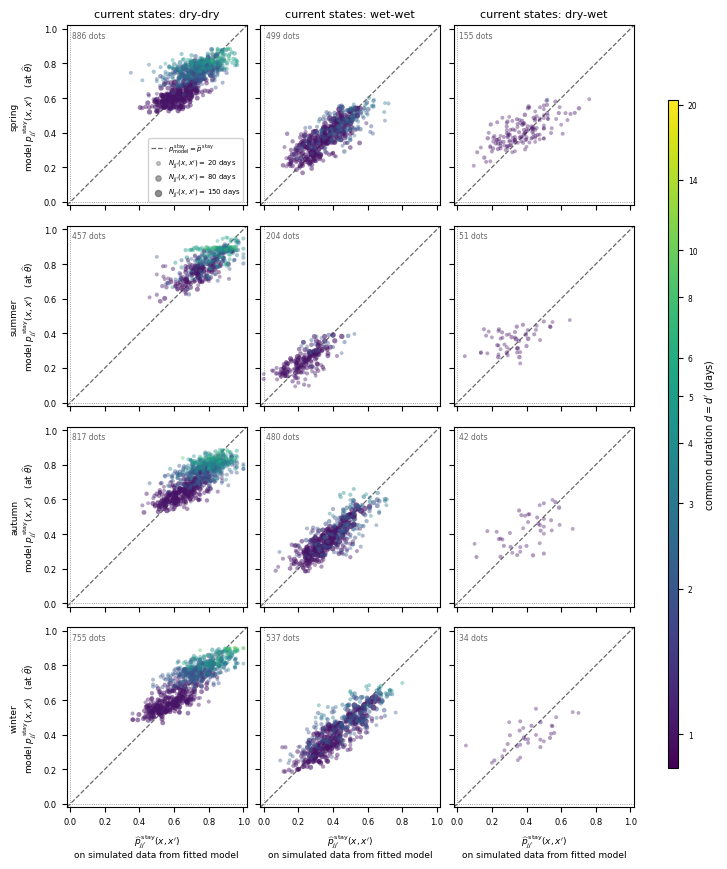

In [6]:
p00_model_obs = {s: p00_model_equal_duration(p00_obs[s], per_season_params[s], theta_by_season[s])
                 for s in SEASONS}
p00_model_sim = {s: p00_model_equal_duration(p00_sim[s], per_season_params[s], theta_by_season[s])
                 for s in SEASONS}

common = dict(
    obs_col="p00", model_col="p00_model",
    seasons=SEASONS, min_n=P00_MIN_N, d_max=D_MAX, n_ref=N_REF_P00,
    legend_ns=(20, 80, 150), lims=(-0.02, 1.02),
    ylabel=r"model $p^{\,\mathrm{stay}}_{jj'}(x,x')$   (at $\widehat{\theta}$)",
    identity_label=r"$p^{\,\mathrm{stay}}_{\mathrm{model}} = \widehat{p}^{\,\mathrm{stay}}$",
)
fig_p00_model_obs = plot_psi_model_vs_obs_grid(
    p00_model_obs,
    xlabel=r"$\widehat{p}^{\,\mathrm{stay}}_{jj'}(x,x')$" + "\non observed data",
    filenames=[FIG_DIR / "diag_fitted_model_p00_model_vs_obs.pdf"],
    **common,
)
fig_p00_model_sim = plot_psi_model_vs_obs_grid(
    p00_model_sim,
    xlabel=r"$\widehat{p}^{\,\mathrm{stay}}_{jj'}(x,x')$" + "\non simulated data from fitted model",
    filenames=[FIG_DIR / "diag_fitted_model_p00_model_vs_sim.pdf"],
    **common,
)

summary_kw = dict(obs_col="p00", model_col="p00_model",
                  seasons=SEASONS, min_n=P00_MIN_N, d_max=D_MAX)
p00_summary = pd.concat(
    {"vs observed data": psi_model_vs_obs_summary(p00_model_obs, **summary_kw),
     "vs simulated data from fitted model": psi_model_vs_obs_summary(p00_model_sim, **summary_kw)},
    axis=1,
)
p00_summary.to_csv(OUTPUT_DIR / "p00_model_vs_obs_and_sim_equal_duration_summary.csv")

_cols = ["n_dots", "bias (model - obs)", "rmse", "corr (N-w.)"]
print("p^stay at theta_hat against the estimate, N-weighted -- left: observed data, "
      "right: simulated data from fitted model (pure estimation noise)")
print(p00_summary.loc[:, (slice(None), _cols)].round(3).to_string())

## Much longer simulation: 25 × 41 years of simulated data from fitted model

Every statistic above read on simulated data from fitted model rests on one 41-year trajectory, so it carries the sampling noise of a record as short as the observed one. This section reads the rain-state agreement and the two co-persistence figures again, on a simulation `N_LONG_REPLICATES` times longer — 25 × 41 = 1025 years by default — so that, on the simulated side, what is left is close to the model's own value.

**How the long simulation is built.** `N_LONG_REPLICATES` independent trajectories of `simulate_cholesky_seasonal` at $\widehat{\theta}_s$, each on the observed 1980–2020 calendar with its own `N_BURN`-day burn-in, seeds `SEED_LONG0` onwards — disjoint from `SEED`, so the long simulation is independent of the 41-year one. They are **not** blanked where the observed data are missing: the long simulation has no gaps. Every statistic here is a frequency over the days of one season, and the day-level record is cut at each year boundary anyway, so stacking the trajectories estimates the same quantities as one continuous 1025-year run would. A single continuous run of that length is not possible on a real calendar in any case, since pandas timestamps stop at year 2262.

The trajectories go through `simulate_ensemble_cached` ([simulation_cache.py](simulation_cache.py)): simulated once, then reloaded from `experiment_outputs/sim_ensemble_cache/` on every re-run, keyed by $\widehat{\theta}_s$, the station parameters, the calendar, the seeds and the source of the simulation code. The day records of the trajectories are built one by one and pooled with `stack_day_records`; that is the slow part of a re-run.

In [7]:
from spatial_bmcd.pair_statistics import stack_day_records
from spatial_bmcd.simulation_cache import simulate_ensemble_cached

N_LONG_REPLICATES = 25      # independent 41-year trajectories -> 1025 years of simulated data
SEED_LONG0 = 100            # seeds 100 ... 124, disjoint from SEED
N_SHORT_YEARS = Rbin_obs.index.year.nunique()
N_LONG_YEARS = N_LONG_REPLICATES * N_SHORT_YEARS
LABEL_SIM_LONG = f"simulated data from fitted model, {N_LONG_YEARS} years"

Rbin_long_reps = simulate_ensemble_cached(
    dates=Rbin_obs.index,
    theta_by_season=theta_by_season,
    params_by_season=per_season_params,
    station_names=stations,
    seeds=range(SEED_LONG0, SEED_LONG0 + N_LONG_REPLICATES),
    mask=None,                  # no gaps: the long simulation uses every day
    label="fitted_model_long",
    n_burn=N_BURN,
)

# Per season, the rows of every trajectory (rain-state agreement) and the day
# record of every trajectory (co-persistence), then pooled.
_frames = {s: [] for s in SEASONS}
_records = {s: [] for s in SEASONS}
for k, rep in enumerate(Rbin_long_reps):
    for s, frame in season_frames(rep, SEASONS).items():
        _frames[s].append(frame)
        _records[s].append(day_record_from_Rbin(frame, per_season_params[s]))
    if (k + 1) % 5 == 0:
        print(f"  day records: {k + 1}/{N_LONG_REPLICATES} trajectories", flush=True)
Rbin_long_by_season = {s: pd.concat(f) for s, f in _frames.items()}
day_record_long = {s: stack_day_records(r) for s, r in _records.items()}
del _frames, _records

for s in SEASONS:
    print(f"[{s:>6}] {day_record_long[s]['B'].shape[0]:>6} days x "
          f"{day_record_long[s]['B'].shape[1]} stations "
          f"(observed data: {day_record_obs[s]['B'].shape[0]} days)")

[fitted_model_long] 25 replicates loaded from cache 8394f0d08c3f55be (delete fitted_model_long_8394f0d08c3f55be.npz or pass refresh=True to re-simulate)


  day records: 5/25 trajectories


  day records: 10/25 trajectories


  day records: 15/25 trajectories


  day records: 20/25 trajectories


  day records: 25/25 trajectories


[spring]  93275 days x 26 stations (observed data: 3731 days)
[summer]  93275 days x 26 stations (observed data: 3731 days)
[autumn]  92250 days x 26 stations (observed data: 3690 days)
[winter]  91500 days x 26 stations (observed data: 3660 days)


### Rain-state agreement $\widehat{\pi}_{jj'}$ on the long simulation

The figure of the rain-state agreement section, with the long simulation in blue. A blue dot now rests on about 30 times more days than a black one — 25 trajectories, and no missing days — so its sampling noise is roughly five times smaller: the blue cloud is close to the model's own $\pi_{jj'}$, pair by pair. The gap between the two colours is then the model's departure plus the noise of the observed data alone.

**Reading.** The table puts the comparison beside the one made with the 41-year simulated data from fitted model. If the bias stays where it was, the gap seen in the rain-state agreement section is the model and not the draw; the RMSE shrinks little either way, since it also carries the noise of the observed data.

pi_hat on simulated data from fitted model against pi_hat on observed data, pair by pair
(observed data: median spring 0.722, summer 0.827, autumn 0.744, winter 0.728)
       simulated data from fitted model, 41 years                                                     simulated data from fitted model, 1025 years                                                    
                                       sim median bias (sim - obs, N-w.) rmse (N-w.) spearman(sim, h)                                   sim median bias (sim - obs, N-w.) rmse (N-w.) spearman(sim, h)
season                                                                                                                                                                                                
spring                                      0.673                 -0.040       0.061           -0.643                                        0.670                 -0.038       0.059           -0.627
summer                              

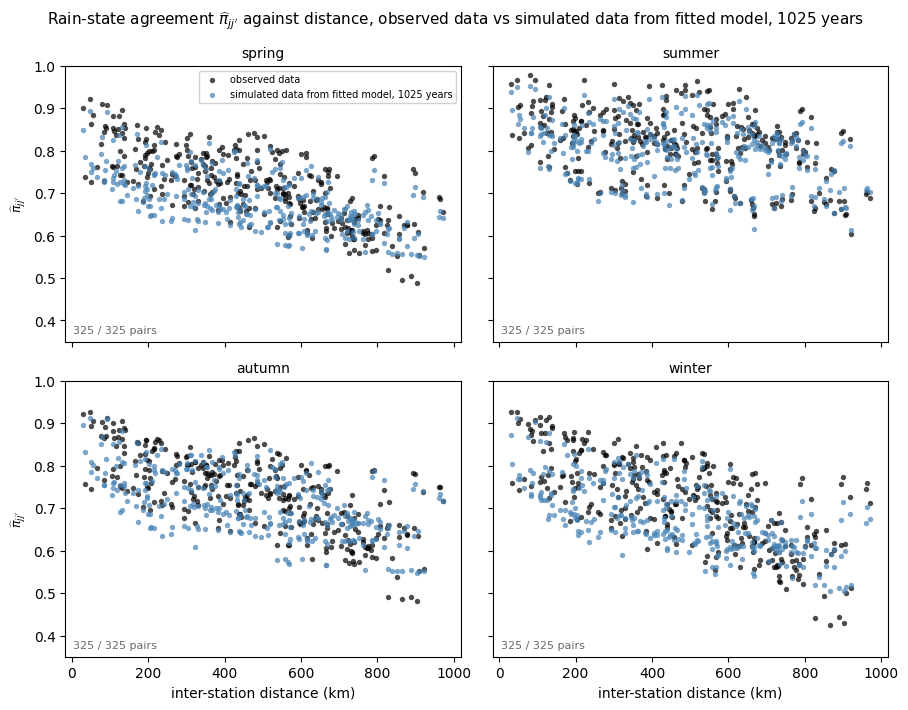

In [8]:
agree_long = {s: state_agreement_table(Rbin_long_by_season[s], per_season_params[s])
              for s in SEASONS}

fig_agree_long = plot_agreement_obs_vs_sim(
    agree_obs, agree_long,
    labels=(LABEL_OBS, LABEL_SIM_LONG), colors=(COLOR_OBS, COLOR_SIM),
    ncols=2, trend=False,
    y_range=(0.35, 1.0),   # same fixed axis as the rain-state agreement section
    suptitle=r"Rain-state agreement $\widehat{\pi}_{jj'}$ against distance, "
             f"observed data vs {LABEL_SIM_LONG}",
    filenames=[FIG_DIR / "diag_fitted_model_state_agreement_obs_vs_sim_long.pdf"],
)

agree_both = pd.concat(
    {f"simulated data from fitted model, {N_SHORT_YEARS} years": agree_summary,
     LABEL_SIM_LONG: agreement_obs_vs_sim_summary(agree_obs, agree_long)},
    axis=1,
)
agree_both.to_csv(OUTPUT_DIR / "state_agreement_obs_vs_sim_long_summary.csv")
_cols_agree = ["sim median", "bias (sim - obs, N-w.)", "rmse (N-w.)", "spearman(sim, h)"]
print("pi_hat on simulated data from fitted model against pi_hat on observed data, pair by pair")
print("(observed data: median " + ", ".join(
    f"{s} {agree_summary.loc[s, 'obs median']:.3f}" for s in SEASONS) + ")")
print(agree_both.loc[:, (slice(None), _cols_agree)].round(3).to_string())

### Co-persistence $\widehat{p}^{\,\mathrm{stay}}$ on the long simulation

The two co-persistence figures for simulated data from fitted model, read on the long simulation: $\widehat{p}^{\,\mathrm{stay}}$ against distance, then $p^{\,\mathrm{stay}}$ at $\widehat{\theta}$ against it. The admissibility rule stays $N_{jj'}(x,x') \geq 20$, but with about 30 times more days most cells clear it by far, including discordant ones the 41-year simulated data from fitted model could not fill. Dot size and opacity are scaled on the long table's own largest cell, so a dot of a given size stands for a much larger $N$ than in the figures above — read the legend.

**Reading.** The second figure checks the model against its own simulator: the data were generated at $\widehat{\theta}$ and the cells are now large, so the cloud should sit on the identity line up to the noise of the smallest cells. A systematic offset in one class would point at a mismatch between the formula for $p^{\,\mathrm{stay}}$ and what the simulator does — the fast $\Phi_2$, the clipping of $q$, the rule that a spell keeps the exit probabilities of the season it started in — and not at the data. The table sets the three comparisons side by side: the model against observed data, against the 41-year simulated data from fitted model, and against the long simulation.

[spring] cells with N >= 20: observed data  1921, simulated data from fitted model, 1025 years 10626
[summer] cells with N >= 20: observed data   848, simulated data from fitted model, 1025 years  9130
[autumn] cells with N >= 20: observed data  1911, simulated data from fitted model, 1025 years 10256
[winter] cells with N >= 20: observed data  1785, simulated data from fitted model, 1025 years 10859



p^stay at theta_hat against the estimate, N-weighted:
               vs observed data                           vs simulated data from fitted model, 41 years                           vs simulated data from fitted model, 1025 years                          
                         n_dots bias (model - obs)   rmse                                        n_dots bias (model - obs)   rmse                                          n_dots bias (model - obs)   rmse
season class                                                                                                                                                                                               
spring dry-dry              962              0.001  0.073                                           886              0.009  0.069                                            5680              0.000  0.019
       wet-wet              538             -0.045  0.087                                           499              0.015  0.066

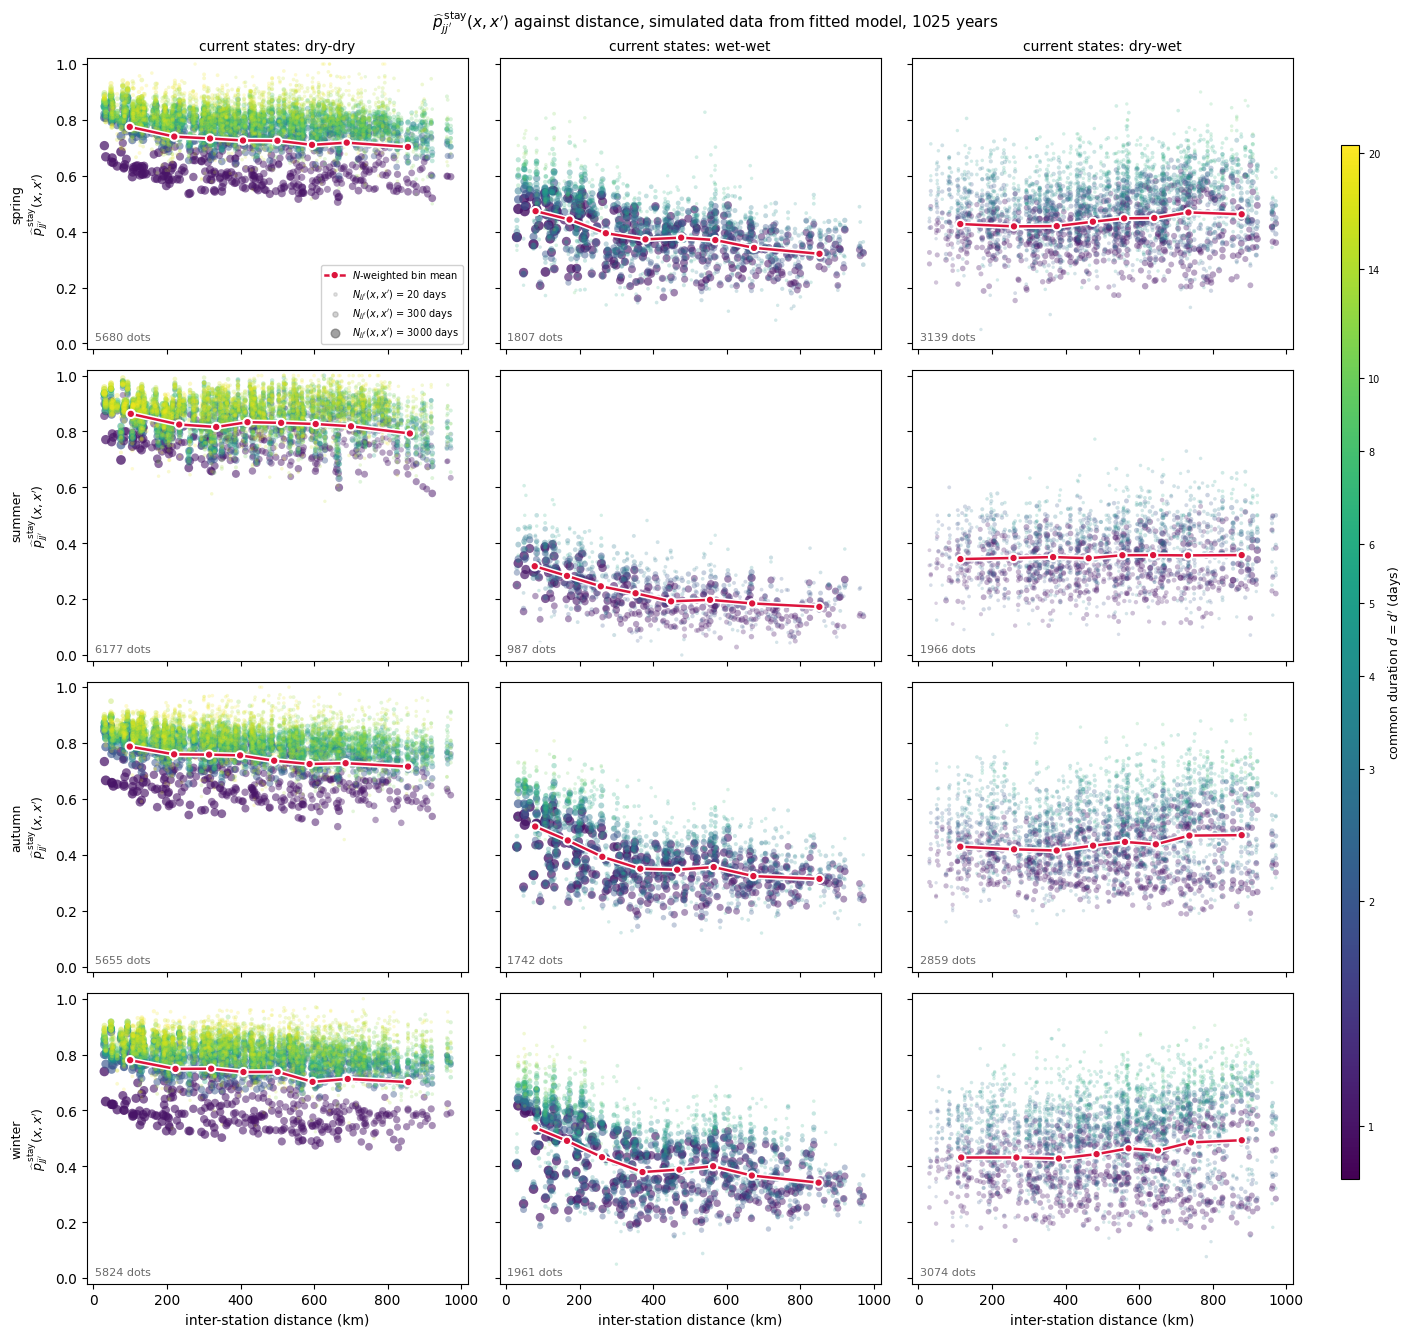

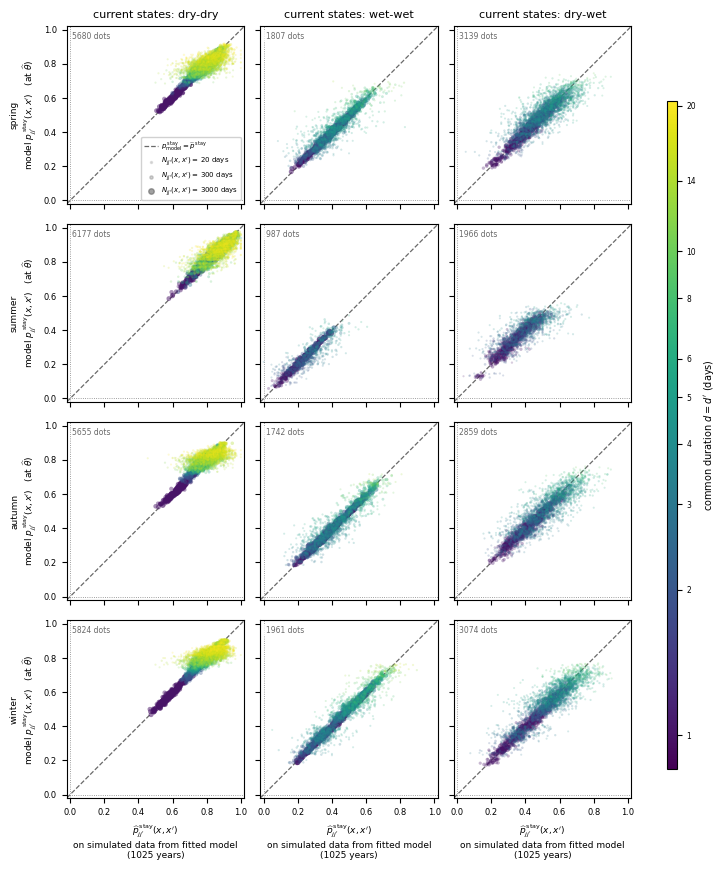

In [9]:
p00_long = {s: equal_duration_metric_table(day_record_long[s], p00_cell_metrics)
            for s in SEASONS}
p00_model_long = {s: p00_model_equal_duration(p00_long[s], per_season_params[s],
                                              theta_by_season[s])
                  for s in SEASONS}

# Own dot-size reference: the long cells are much larger than the observed
# ones, and the shared N_REF_P00 would draw every dot at the maximum size.
N_REF_LONG = float(max(t["n_days"].max() for t in p00_long.values()))
_round1 = lambda v: int(float(f"{v:.1g}"))      # one significant digit
LEGEND_NS_LONG = (P00_MIN_N, _round1(N_REF_LONG / 20), _round1(N_REF_LONG / 2))

for s in SEASONS:
    n_o = int((p00_obs[s]["n_days"] >= P00_MIN_N).sum())
    n_l = int((p00_long[s]["n_days"] >= P00_MIN_N).sum())
    print(f"[{s:>6}] cells with N >= {P00_MIN_N}: observed data {n_o:>5}, "
          f"{LABEL_SIM_LONG} {n_l:>5}")

plot_equal_duration_metric_grid(
    p00_long, value_col="p00", value_label=P00_LABEL,
    y_range=(-0.02, 1.02),
    min_n=P00_MIN_N, n_ref=N_REF_LONG, legend_ns=LEGEND_NS_LONG,
    suptitle=P00_LABEL + f" against distance, {LABEL_SIM_LONG}",
    filenames=[FIG_DIR / "diag_fitted_model_p00_equal_duration_sim_long.pdf"],
)

fig_p00_model_long = plot_psi_model_vs_obs_grid(
    p00_model_long,
    xlabel=(r"$\widehat{p}^{\,\mathrm{stay}}_{jj'}(x,x')$" + "\non simulated data from fitted model"
            + f"\n({N_LONG_YEARS} years)"),
    filenames=[FIG_DIR / "diag_fitted_model_p00_model_vs_sim_long.pdf"],
    **dict(common, n_ref=N_REF_LONG, legend_ns=LEGEND_NS_LONG),
)

p00_summary_long = pd.concat(
    {"vs observed data": psi_model_vs_obs_summary(p00_model_obs, **summary_kw),
     f"vs simulated data from fitted model, {N_SHORT_YEARS} years":
         psi_model_vs_obs_summary(p00_model_sim, **summary_kw),
     f"vs {LABEL_SIM_LONG}": psi_model_vs_obs_summary(p00_model_long, **summary_kw)},
    axis=1,
)
p00_summary_long.to_csv(OUTPUT_DIR / "p00_model_vs_obs_and_sim_long_equal_duration_summary.csv")
_cols_p00 = ["n_dots", "bias (model - obs)", "rmse"]
print("\np^stay at theta_hat against the estimate, N-weighted:")
print(p00_summary_long.loc[:, (slice(None), _cols_p00)].round(3).to_string())